<a href="https://colab.research.google.com/github/chl-eo/CCADMACL_EXAM_COM222ML/blob/main/Exercise6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 6

In [262]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [263]:
import numpy as np
import pandas as pd

path = "https://github.com/robitussin/CCDEPLRL_EXERCISES/blob/9b8ac1c5683abecc144f0af47eb7cda0688e12b7/dataset/reviews.json?raw=true"

dataset = pd.read_json(path)

In [264]:
dataset.head()

,review,rating
0,sir okay armygreen shorts nice,5
1,di pareha yong mga size nila may sobrang liit ...,5
2,super worth it ang ganda Sombra grabi order na...,5
3,ganda po salamat,5
4,maayos pagkadeliver maganda den sya,5


## 1. Tokenize the data

In [265]:
import numpy as np
import pandas as pd

sentences = dataset['review'].tolist()
labels = dataset['rating'].tolist()

training_size = int(len(sentences) * 0.8)

training_sentences = sentences[0:training_size]
testing_sentences = sentences[training_size:]
training_labels = labels[0:training_size]
testing_labels = labels[training_size:]

training_labels_final = np.array(training_labels)
testing_labels_final = np.array(testing_labels)

In [266]:
# prompt: Training labels ranges from 1 - 5. Make it 0 if it's 1-2 and 1 if it's 3-5

training_labels_final = np.array([0 if x <= 2 else 1 for x in training_labels])
testing_labels_final = np.array([0 if x <= 2 else 1 for x in testing_labels])

## 2. Sequence the data

In [341]:
vocab_size = 4000
embedding_dim = 16
max_length = 24
trunc_type='pre'
padding_type='post'
oov_tok = ""

tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index
training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [331]:
print(word_index['panget'])


520


## 3. Pad the data

In [332]:
padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type) # Changed line

print("\nWord Index = " , word_index)
# Print the sequences variable that was padded
print("\nSequences = " , training_sequences) # Changed line
print("\nPadded Sequences:")
print(padded)


Word Index =  {'': 1, 'the': 2, 'na': 3, 'i': 4, 'ko': 5, 'sa': 6, 'yung': 7, 'and': 8, 'ang': 9, 'ng': 10, 'it': 11, 'lang': 12, 'is': 13, 'at': 14, 'you': 15, 'seller': 16, 'naman': 17, 'to': 18, 'for': 19, 'not': 20, 'po': 21, 'sya': 22, 'maganda': 23, 'order': 24, 'pa': 25, 'but': 26, 'thank': 27, 'pero': 28, 'a': 29, 'good': 30, 'item': 31, 'product': 32, 'hindi': 33, 'so': 34, 'sana': 35, 'my': 36, 'ung': 37, 'dumating': 38, 'this': 39, 'ok': 40, 'delivery': 41, 'di': 42, 'was': 43, 'din': 44, 'its': 45, 'may': 46, 'quality': 47, 'in': 48, 'color': 49, 'price': 50, 'working': 51, 'very': 52, 'of': 53, 'ako': 54, 'ganda': 55, 'that': 56, 'me': 57, 'lng': 58, 'well': 59, 'buy': 60, 'with': 61, 'size': 62, 'mga': 63, 'fast': 64, 'as': 65, 'nice': 66, 'nyo': 67, 'will': 68, 'time': 69, 'nya': 70, 'siya': 71, '1': 72, 'black': 73, 'just': 74, 'items': 75, 'lazada': 76, 'thanks': 77, 'kasi': 78, 'are': 79, 'okay': 80, 'much': 81, 'kaso': 82, 'nmn': 83, 'on': 84, 'kaya': 85, '2': 86, '

In [333]:
# Specify a max length for the padded sequences
padded = pad_sequences(training_sequences, maxlen=15)
print(padded)

[[  0   0   0 ...   1 390  66]
 [  0   0   0 ...  89   1   1]
 [ 24   3 100 ...   9 168  38]
 ...
 [431  20   1 ... 218   1  75]
 [  0   0   0 ... 159  38 444]
 [ 35   1   5 ...  87 464  12]]


In [334]:
# Put the padding at the end of the sequences
padded = pad_sequences(training_sequences, maxlen=15, padding="post")
print(padded)

[[  1  80   1 ...   0   0   0]
 [ 42   1   1 ...   0   0   0]
 [ 24   3 100 ...   9 168  38]
 ...
 [431  20   1 ... 218   1  75]
 [  9 273  38 ...   0   0   0]
 [ 35   1   5 ...  87 464  12]]


In [335]:
# Limit the length of the sequences, you will see some sequences get truncated
padded = pad_sequences(training_sequences, maxlen=3)
print(padded)

[[  1 390  66]
 [ 89   1   1]
 [  9 168  38]
 ...
 [218   1  75]
 [159  38 444]
 [ 87 464  12]]


In [336]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

# Assuming you want to decode a sequence from the training set
print(decode_review(training_padded[1]))
print(training_sentences[1])

di   mga size nila may sobrang   ? ? ? ? ? ? ? ? ? ? ? ? ? ?
di pareha yong mga size nila may sobrang liit akjejrjrjjfjjriro4k4jrjrjfjrjrjrjrjjtjrj


## 4. Train a sentiment model

In [342]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_30     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [343]:
num_epochs = 100
history = model.fit(training_padded, training_labels_final, epochs=num_epochs, validation_data=(testing_padded, testing_labels_final))


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6853 - loss: 0.6772 - val_accuracy: 0.3234 - val_loss: 0.7674
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6898 - loss: 0.6387 - val_accuracy: 0.3234 - val_loss: 0.8396
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7172 - loss: 0.6083 - val_accuracy: 0.3234 - val_loss: 0.8881
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6995 - loss: 0.6101 - val_accuracy: 0.3234 - val_loss: 0.8890
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7017 - loss: 0.6078 - val_accuracy: 0.3234 - val_loss: 0.8991
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6921 - loss: 0.6118 - val_accuracy: 0.3234 - val_loss: 0.8874
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6915 - loss: 0.6075 - val_accuracy: 0.3234 - val_loss: 0.8973
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7083 - loss: 0.5919 - val_accuracy: 0.3234 - 

## Get files for visualing the network

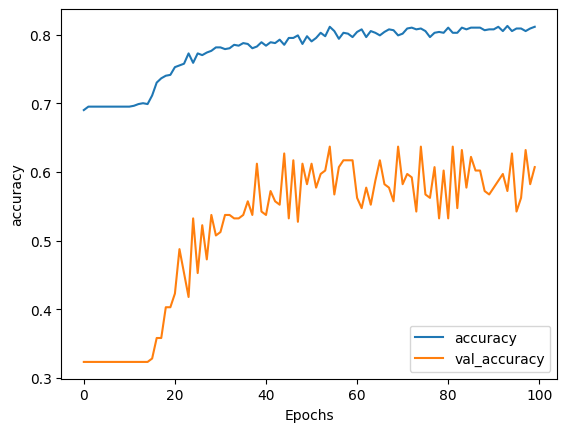

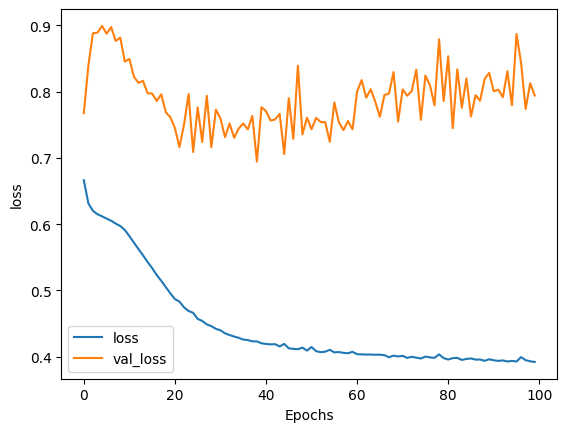

In [345]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

## 5. Predict sentiment with new reviews

In [357]:
def predict_review(review):
    # Tokenize and pad the new review
    sequence = tokenizer.texts_to_sequences([review])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    # Make the prediction
    prediction = model.predict(padded_sequence)

    # Determine sentiment based on the prediction
    if prediction[0][0] > 0.5:
        return "Positive review", prediction[0][0]
    else:
        return "Negative review", prediction[0][0]

# Example usage:
custom_review = "sakto lang"
sentiment, probability = predict_review(custom_review)
print(f"Review: '{custom_review}'\nSentiment: {sentiment} (Probability: {probability:.4f})")

custom_review = "Bobo nyo bwisit. Tang inang item to. Sayang nakaka galit! Wag na wag na kayo dito sira sira"
sentiment, probability = predict_review(custom_review)
print(f"Review: '{custom_review}'\nSentiment: {sentiment} (Probability: {probability:.4f})")

custom_review = "Napaka ganda ng item. Bibili ako ulit. Thank you seller mwamwa"
sentiment, probability = predict_review(custom_review)
print(f"Review: '{custom_review}'\nSentiment: {sentiment} (Probability: {probability:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Review: 'sakto lang'
Sentiment: Positive review (Probability: 0.5340)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Review: 'Bobo nyo bwisit. Tang inang item to. Sayang nakaka galit! Wag na wag na kayo dito sira sira'
Sentiment: Negative review (Probability: 0.1575)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Review: 'Napaka ganda ng item. Bibili ako ulit. Thank you seller mwamwa'
Sentiment: Positive review (Probability: 0.9813)
